In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [3]:
data = pd.read_csv("Life Expectancy Data.csv")

In [4]:
print("\nData Overview:")
print(data.info())

print("\nSummary Stat:")
print(data.describe())


Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Poli

In [5]:
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

Life expectancy                     10
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
 BMI                                34
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64


In [6]:
input_cols = ["Life expectancy", "Schooling", "Income composition of resources", "Status", "Adult Mortality"]
exclude_cols = list(set(data.columns) - set(input_cols))

print("\nColumns to Exclude: ", exclude_cols)


Columns to Exclude:  ['GDP', 'under-five deaths ', ' thinness 5-9 years', ' BMI ', 'infant deaths', 'Population', ' thinness  1-19 years', ' HIV/AIDS', 'Total expenditure', 'Hepatitis B', 'Measles ', 'Year', 'Life expectancy ', 'Diphtheria ', 'percentage expenditure', 'Polio', 'Alcohol', 'Country']


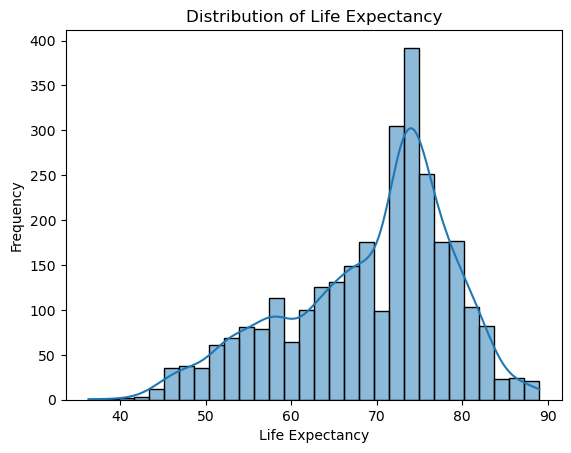

In [7]:
sns.histplot(data['Life expectancy '].dropna(), kde=True)
plt.title("Distribution of Life Expectancy")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.show()

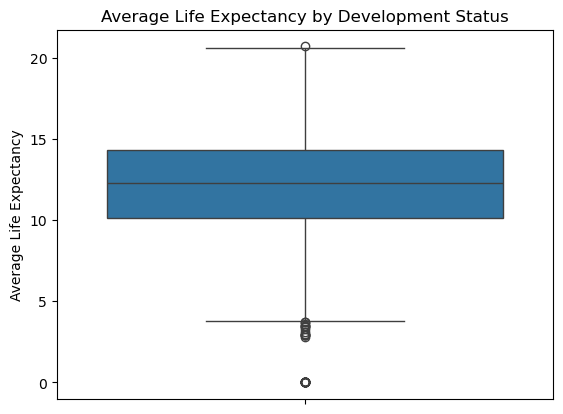

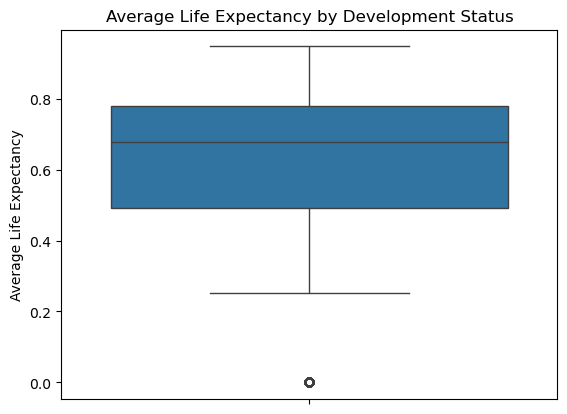

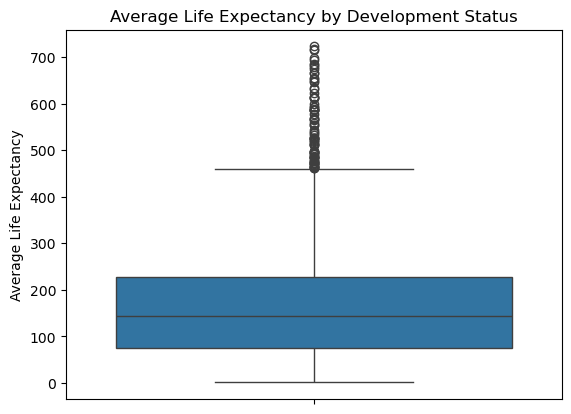

In [8]:
for col in ["Schooling", "Income composition of resources", "Adult Mortality"]:
    sns.boxplot(data[col].dropna())
    plt.title("Average Life Expectancy by Development Status")
    plt.ylabel("Average Life Expectancy")
    plt.show()

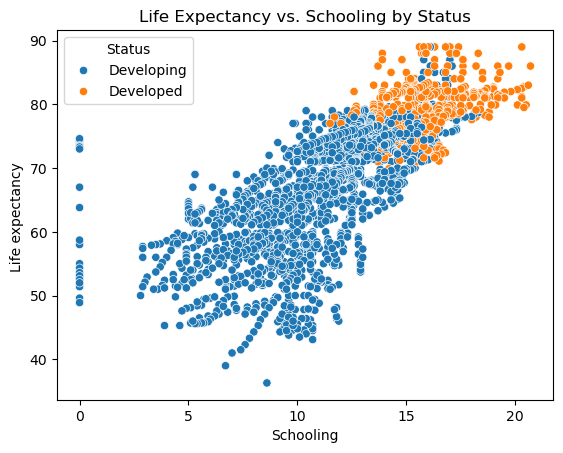

In [9]:
sns.scatterplot(data=data, x="Schooling", y="Life expectancy ", hue="Status")
plt.title("Life Expectancy vs. Schooling by Status")
plt.show()

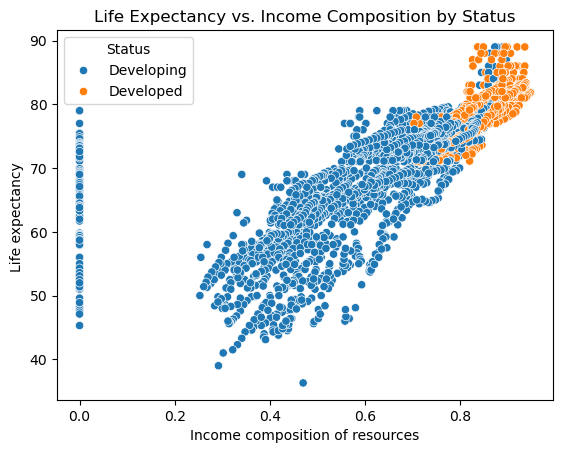

In [10]:
sns.scatterplot(data=data, x="Income composition of resources", y="Life expectancy ", hue="Status")
plt.title("Life Expectancy vs. Income Composition by Status")
plt.show()

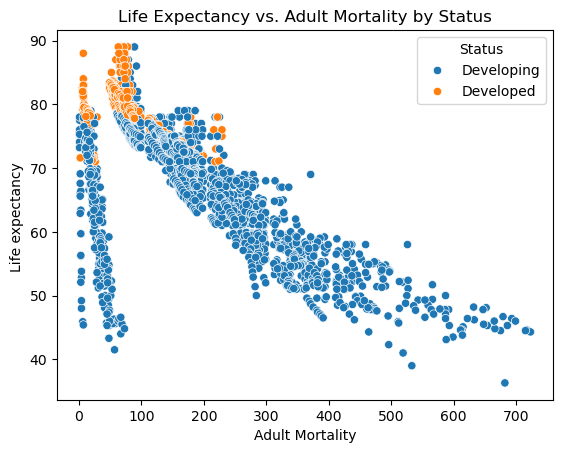

In [11]:
sns.scatterplot(data=data, x="Adult Mortality", y="Life expectancy ", hue="Status")
plt.title("Life Expectancy vs. Adult Mortality by Status")
plt.show()


In [21]:
numeric_cols = data.select_dtypes(include=["float64", "int64"]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

data["Status"] = data["Status"].apply(lambda x: 1 if x == "Developed" else 0)

scaler = StandardScaler()
features_to_scale = ["Schooling", "Income composition of resources", "Adult Mortality"]
data[features_to_scale] = scaler.fit_transform(data[features_to_scale])

In [22]:
scaler = StandardScaler()
data[["Schooling", "Income composition of resources", "Adult Mortality"]] = scaler.fit_transform(data[["Schooling", "Income composition of resources", "Adult Mortality"]])

In [23]:
X = data[["Schooling", "Income composition of resources", "Status", "Adult Mortality"]]
y = data["Life expectancy "]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = lr.predict(X_test)
print("\nModel Coefficients:", lr.coef_)
print("Intercept:", lr.intercept_)


Model Coefficients: [ 3.06527441  2.26294796  0.         -4.37437188]
Intercept: 69.25546561768243


In [27]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nMean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 25.872419938020705
R-squared: 0.701474484115437


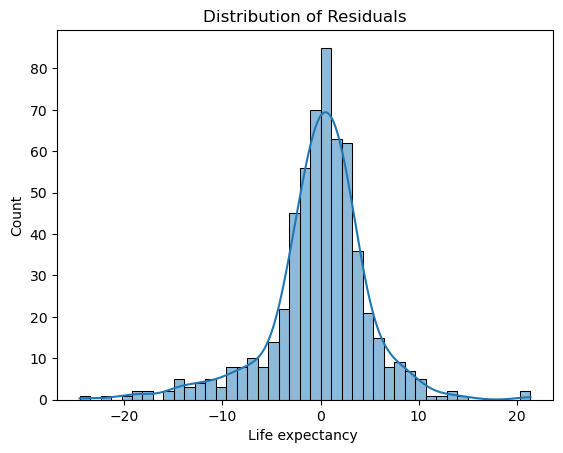

In [28]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

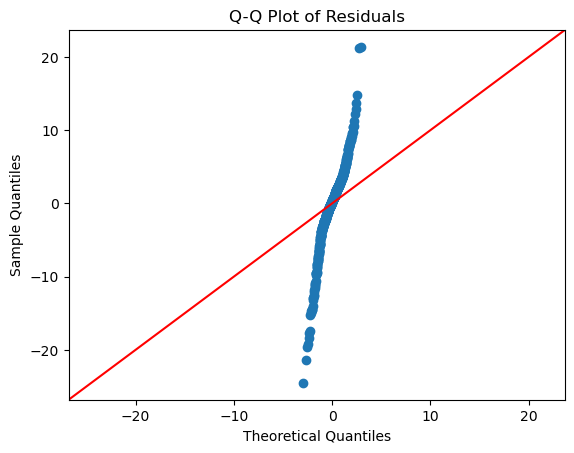

In [29]:
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

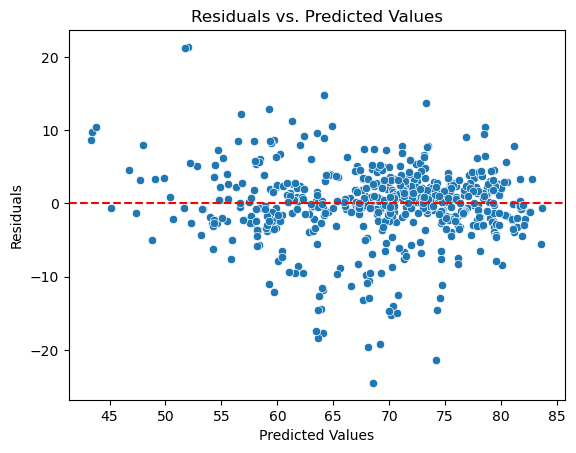

In [30]:
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals vs. Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

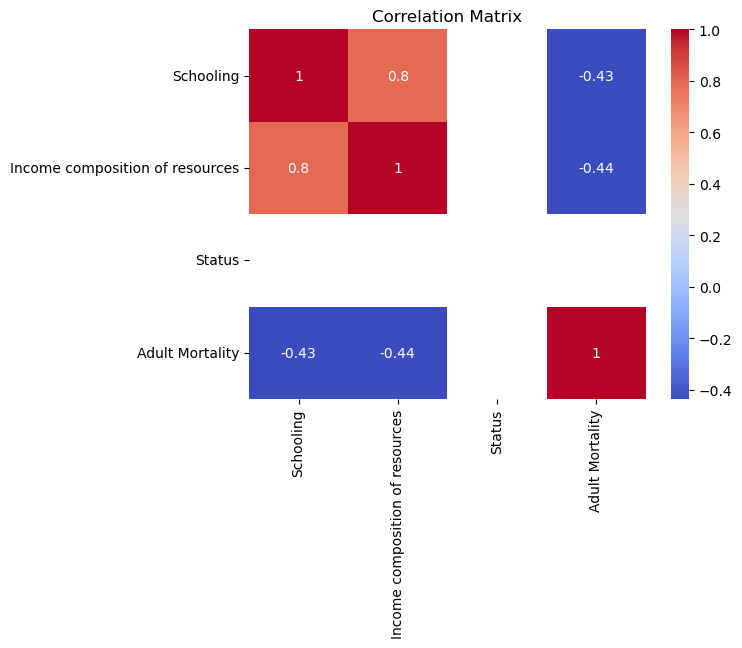

In [31]:
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()